In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
print('repo root added to sys.path:', sys.path[0])


repo root added to sys.path: c:\Users\kaleo\python-csv-order-analyzer


# CSV Order Analyzer — Demo Notebook

This notebook demonstrates how to load sample order data, run the project's
processing and summarization functions, inspect cleaned and invalid rows,
and visualize revenue by product and by customer.


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from src.processing import classify_orders
from src.summary import summarize_orders, format_report

%matplotlib inline


In [3]:
# Load sample dataset
csv_path = "../data/sample_orders.csv"
df = pd.read_csv(csv_path)

df.head()


,order_id,customer,product,quantity,unit_price,order_date
0,2001.0,Alice,Li Hing Plum,3,28.25,2026-05-10
1,2002.0,Bob,Nibb-its,2,2.02,2026-05-10
2,2003.0,Charlie,Li Hing Mango,1,28.25,2026-05-11
3,2004.0,Dana,Nibb-its,5,2.02,2026-05-12
4,2005.0,Ed,Li Hing Plum,2,28.25,2026-05-13


In [4]:
# Classify rows using the project's processing function
rows = df.to_dict(orient="records")
valid, invalid, duplicates = classify_orders(rows)

df_valid = pd.DataFrame(valid)
df_invalid = pd.DataFrame(invalid)
df_duplicates = pd.DataFrame(duplicates)

print("Original rows:", len(df))
print("Valid:", len(df_valid))
print("Invalid:", len(df_invalid))
print("Duplicates:", len(df_duplicates))

# Show cleaned orders
df_valid.head()


Original rows: 9
Valid: 7
Invalid: 2
Duplicates: 0


,order_id,customer,product,quantity,unit_price,order_date,revenue
0,2001.0,Alice,Li Hing Plum,3,28.25,2026-05-10,84.75
1,2002.0,Bob,Nibb-its,2,2.02,2026-05-10,4.04
2,2003.0,Charlie,Li Hing Mango,1,28.25,2026-05-11,28.25
3,2004.0,Dana,Nibb-its,5,2.02,2026-05-12,10.10
4,2005.0,Ed,Li Hing Plum,2,28.25,2026-05-13,56.50


In [5]:
# Summarize and print human-readable report
summary = summarize_orders(valid, invalid, duplicates)
print(format_report(summary))

# Show top of cleaned orders DataFrame
if not df_valid.empty:
    display(df_valid.head())


Sales Data Quality Report
-------------------------
Valid orders: 7
Invalid orders: 2
Duplicate orders: 0
Total revenue: $219.97
Average order value: $31.42
Best product: Li Hing Plum ($169.50)
Best customer: Alice ($84.75)

Revenue by Product
------------------
Li Hing Plum: $169.50
Li Hing Mango: $28.25
Nibb-its: $14.14
nan: $8.08

Revenue by Customer
-------------------
Alice: $84.75
Ed: $56.50
Charlie: $28.25
Henry: $28.25
Dana: $10.10
Fran: $8.08
Bob: $4.04

Error Breakdown
---------------
Quantity must be positive: 1
Invalid quantity or unit price: 1



,order_id,customer,product,quantity,unit_price,order_date,revenue
0,2001.0,Alice,Li Hing Plum,3,28.25,2026-05-10,84.75
1,2002.0,Bob,Nibb-its,2,2.02,2026-05-10,4.04
2,2003.0,Charlie,Li Hing Mango,1,28.25,2026-05-11,28.25
3,2004.0,Dana,Nibb-its,5,2.02,2026-05-12,10.10
4,2005.0,Ed,Li Hing Plum,2,28.25,2026-05-13,56.50


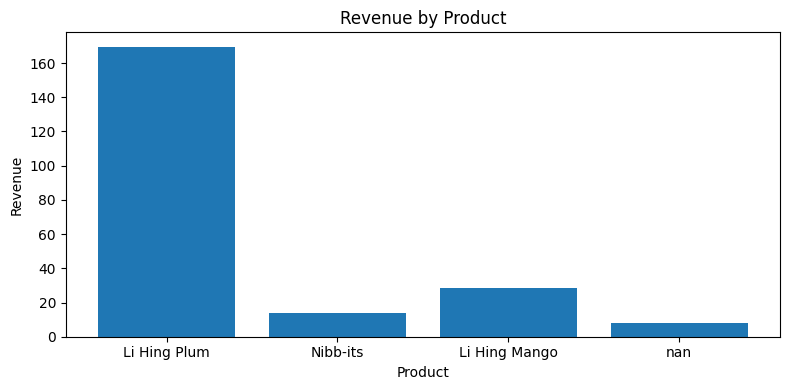

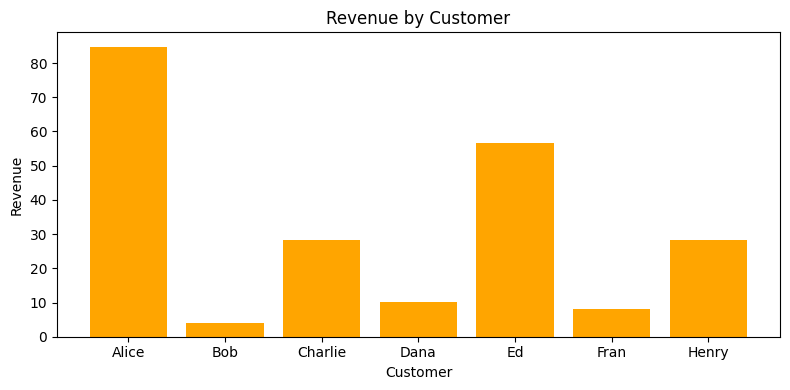

In [6]:
# Plot revenue by product and by customer
product_revenue = summary['product_sales']
customer_revenue = summary['customer_sales']

# Plot product revenue
plt.figure(figsize=(8,4))
plt.bar(product_revenue.keys(), product_revenue.values())
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.xlabel('Product')
plt.tight_layout()
plt.show()

# Plot customer revenue
plt.figure(figsize=(8,4))
plt.bar(customer_revenue.keys(), customer_revenue.values(), color='orange')
plt.title('Revenue by Customer')
plt.ylabel('Revenue')
plt.xlabel('Customer')
plt.tight_layout()
plt.show()


# CLI instructions

To run the same processing from the command line, execute:

```bash
python ../src/main.py --input ../data/sample_orders.csv --reports-dir ../reports
```

This will write the cleaned, invalid, and duplicate CSVs to the `reports/` directory and a `summary.txt` file.
